In [5]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

accounts = pd.read_csv('accounts.csv')
data_dictionary = pd.read_csv('data_dictionary.csv')
products = pd.read_csv('products.csv')
sales_teams = pd.read_csv('sales_teams.csv')
sales_pipeline = pd.read_csv('sales_pipeline.csv')

# Step 3: Quick look at each table
for name, df in [('Accounts', accounts), ('Data_dictionary', data_dictionary), 
                  ('Products', products), ('Sales Team', sales_teams), 
                  ('Sales pipeline', sales_pipeline)]:
    print(f"\n{'='*50}")
    print(f"TABLE:", name)
    print(f"Shape:", df.shape)
    print(f"Columns: {list(df.columns)}")
    print(f"Missing values:\n{df.isnull().sum()}")
    print(f"Dtypes:\n{df.dtypes}")
    print(df.head(2))


TABLE: Accounts
Shape: (85, 7)
Columns: ['account', 'sector', 'year_established', 'revenue', 'employees', 'office_location', 'subsidiary_of']
Missing values:
account              0
sector               0
year_established     0
revenue              0
employees            0
office_location      0
subsidiary_of       70
dtype: int64
Dtypes:
account              object
sector               object
year_established      int64
revenue             float64
employees             int64
office_location      object
subsidiary_of        object
dtype: object
            account     sector  year_established  revenue  employees  \
0  Acme Corporation  technolgy              1996  1100.04       2822   
1        Betasoloin    medical              1999   251.41        495   

  office_location subsidiary_of  
0   United States           NaN  
1   United States           NaN  

TABLE: Data_dictionary
Shape: (21, 3)
Columns: ['Table', 'Field', 'Description']
Missing values:
Table          0
Field          

In [7]:
# --- Accounts ---
print("Before cleaning - Accounts:", accounts.shape)
accounts = accounts.drop_duplicates()
accounts['sector'] = accounts['sector'].str.strip().str.lower()
accounts['sector'] = accounts['sector'].replace('technolgy', 'technology')
print("Sectors:", accounts['sector'].value_counts())

accounts['subsidiary_of'] = accounts['subsidiary_of'].fillna('Independent')

print("After cleaning - Accounts:", accounts.shape)
print(accounts.head())

Before cleaning - Accounts: (85, 7)
Sectors: sector
retail                17
technology            12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64
After cleaning - Accounts: (85, 7)
            account      sector  year_established  revenue  employees  \
0  Acme Corporation  technology              1996  1100.04       2822   
1        Betasoloin     medical              1999   251.41        495   
2          Betatech     medical              1986   647.18       1185   
3        Bioholding     medical              2012   587.34       1356   
4           Bioplex     medical              1991   326.82       1016   

  office_location subsidiary_of  
0   United States   Independent  
1   United States   Independent  
2           Kenya   Independent  
3      Philipines   Independent  
4   United States   Independ

In [9]:
# --- Products ---
print("\nBefore cleaning - Products:", products.shape)
products = products.drop_duplicates()
products['product'] = products['product'].str.strip()
products['series'] = products['series'].str.strip()
print("Products:", products['product'].unique())
print("Price range:", products['sales_price'].min(), "-", products['sales_price'].max())


Before cleaning - Products: (7, 3)
Products: ['GTX Basic' 'GTX Pro' 'MG Special' 'MG Advanced' 'GTX Plus Pro'
 'GTX Plus Basic' 'GTK 500']
Price range: 55 - 26768


In [11]:
# --- Sales Team ---
print("\nBefore cleaning - Sales Team:", sales_team.shape)
sales_team = sales_team.drop_duplicates()
sales_team['sales_agent'] = sales_team['sales_agent'].str.strip()
sales_team['manager'] = sales_team['manager'].str.strip()
print("Managers:", sales_team['manager'].unique())
print("Regions:", sales_team['regional_office'].unique())


Before cleaning - Sales Team: (35, 3)
Managers: ['Dustin Brinkmann' 'Melvin Marxen' 'Cara Losch' 'Rocco Neubert'
 'Celia Rouche' 'Summer Sewald']
Regions: ['Central' 'East' 'West']


In [15]:
# --- Sales Pipeline (main— 8800 rows)
print("\nBefore cleaning - Pipeline:", sales_pipeline.shape)
pipeline = sales_pipeline.drop_duplicates()

pipeline['sales_agent'] = pipeline['sales_agent'].str.strip()
pipeline['product'] = pipeline['product'].str.strip()
pipeline['account'] = pipeline['account'].str.strip()
pipeline['deal_stage'] = pipeline['deal_stage'].str.strip()

pipeline['engage_date'] = pd.to_datetime(pipeline['engage_date'], errors='coerce')
pipeline['close_date'] = pd.to_datetime(pipeline['close_date'], errors='coerce')

print("\nDeal stages:", pipeline['deal_stage'].value_counts())

print("\nMissing values:")
print(f"  account: {pipeline['account'].isnull().sum()} ({pipeline['account'].isnull().mean()*100:.1f}%)")
print(f"  engage_date: {pipeline['engage_date'].isnull().sum()}")
print(f"  close_date: {pipeline['close_date'].isnull().sum()}")
print(f"  close_value: {pipeline['close_value'].isnull().sum()}")

# account missing for 1425 deals — flag but keep them
print("\nAfter cleaning - Pipeline:", pipeline.shape)


Before cleaning - Pipeline: (8800, 8)

Deal stages: deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

Missing values:
  account: 1425 (16.2%)
  engage_date: 500
  close_date: 2089
  close_value: 2089

After cleaning - Pipeline: (8800, 8)


In [19]:
# STEP 2: MERGE(MASTER TABLE)
master = pipeline.merge(sales_team, on='sales_agent', how='left')
print(f"After sales team merge: {master.shape}")

# sector, revenue, employees, location
master = master.merge(accounts,on='account',how='left')
print(f"After accounts merge: {master.shape}")

# series and sales_price
master = master.merge(products, on='product',how='left')
print(f"After products merge: {master.shape}")

print(f"\nFinal master: {master.shape}")
print(f"Columns: {list(master.columns)}")
print(f"\nMissing values:\n{master.isnull().sum()}")
master['deal_duration'] = (master['close_date'] - master['engage_date']).dt.days
master['discount_pct'] = ((master['sales_price'] - master['close_value']) / master['sales_price'] * 100).round(1)

master.to_csv('cleaned_master_dataset.csv', index=False)
print("\nMaster dataset saved")
master.head()

After sales team merge: (8800, 10)
After accounts merge: (8800, 16)
After products merge: (8800, 18)

Final master: (8800, 18)
Columns: ['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value', 'manager', 'regional_office', 'sector', 'year_established', 'revenue', 'employees', 'office_location', 'subsidiary_of', 'series', 'sales_price']

Missing values:
opportunity_id         0
sales_agent            0
product                0
account             1425
deal_stage             0
engage_date          500
close_date          2089
close_value         2089
manager                0
regional_office        0
sector              1425
year_established    1425
revenue             1425
employees           1425
office_location     1425
subsidiary_of       1425
series              1480
sales_price         1480
dtype: int64

Master dataset saved


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,manager,regional_office,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,deal_duration,discount_pct
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Dustin Brinkmann,Central,retail,2001.0,718.62,2448.0,United States,Independent,GTX,1096.0,132.0,3.8
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Melvin Marxen,Central,medical,2002.0,3178.24,4540.0,United States,Independent,NaN,NaN,137.0,NaN
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Melvin Marxen,Central,retail,2001.0,718.62,2448.0,United States,Independent,MG,55.0,133.0,9.1
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Dustin Brinkmann,Central,software,1998.0,2714.90,2641.0,United States,Acme Corporation,GTX,550.0,135.0,-6.9
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Summer Sewald,West,services,1982.0,792.46,1299.0,United States,Independent,GTX,550.0,128.0,6.0


PIPELINE HEALTH
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64

Win Rate: 63.2%
Won: 4238, Lost: 2473

Win Rate by Product:
  GTX Plus Basic: 62.1% (1051 deals)
  GTXPro: 63.6% (1147 deals)
  MG Special: 64.8% (1223 deals)
  GTX Basic: 63.7% (1436 deals)
  MG Advanced: 60.3% (1084 deals)
  GTX Plus Pro: 64.3% (745 deals)
  GTK 500: 60.0% (25 deals)


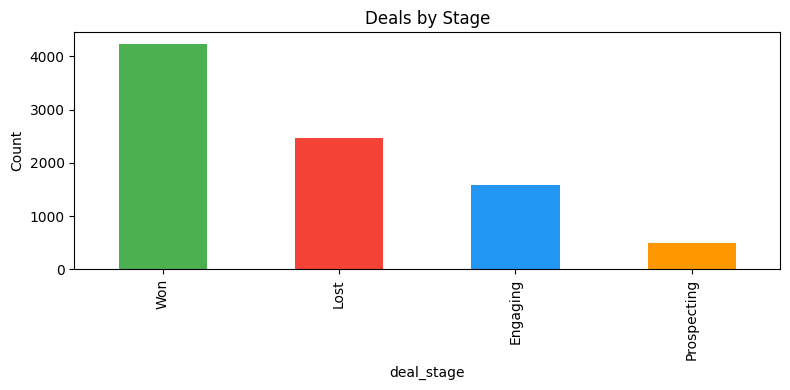

In [21]:
# --- PIPELINE HEALTH ---
print("PIPELINE HEALTH")
print("="*40)

print(master['deal_stage'].value_counts())

won = (master['deal_stage'] == 'Won').sum()
lost = (master['deal_stage'] == 'Lost').sum()
win_rate = won / (won + lost) * 100
print(f"\nWin Rate: {win_rate:.1f}%")
print(f"Won: {won}, Lost: {lost}")

print("\nWin Rate by Product:")
for prod in master['product'].unique():
    df = master[(master['product'] == prod) & (master['deal_stage'].isin(['Won','Lost']))]
    if len(df) > 0:
        wr = (df['deal_stage'] == 'Won').sum() / len(df) * 100
        print(f"  {prod}: {wr:.1f}% ({len(df)} deals)")

plt.figure(figsize=(8, 4))
master['deal_stage'].value_counts().plot(kind='bar', color=['#4CAF50','#f44336','#2196F3','#FF9800'])
plt.title('Deals by Stage')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('pipeline_stages.png')
plt.show()


ACCOUNT PERFORMANCE

Sector Performance:
                    total_revenue  deals_won  avg_deal
sector                                                
retail                  1867528.0        799    2337.0
technology              1515487.0        671    2259.0
medical                 1359595.0        592    2297.0
software                1077934.0        450    2395.0
finance                  950908.0        375    2536.0
marketing                922321.0        404    2283.0
entertainment            689007.0        260    2650.0
telecommunications       653574.0        285    2293.0
services                 533006.0        223    2390.0
employment               436174.0        179    2437.0

Win Rate by Sector:
  retail: 63.1%
  medical: 62.3%
  software: 63.9%
  services: 63.4%
  entertainment: 64.7%
  marketing: 64.8%
  telecommunications: 62.5%
  employment: 62.6%
  finance: 61.2%
  technology: 63.4%

Top 10 Accounts:
account
Kan-code      341455.0
Konex         269245.0
Condax   

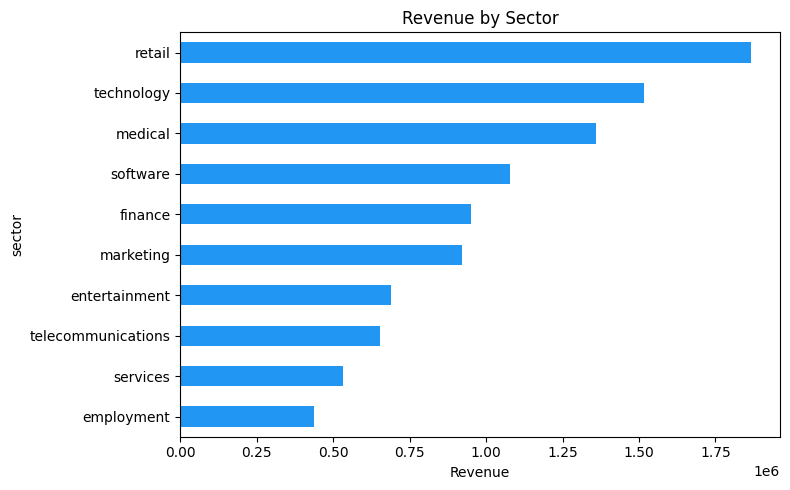

In [23]:
# --- ACCOUNT PERFORMANCE ---
print("\nACCOUNT PERFORMANCE")
print("="*40)
won_deals = master[master['deal_stage'] == 'Won']

sector_rev = won_deals.groupby('sector')['close_value'].agg(['sum','count','mean']).round(0)
sector_rev.columns = ['total_revenue', 'deals_won', 'avg_deal']
sector_rev = sector_rev.sort_values('total_revenue', ascending=False)
print("\nSector Performance:")
print(sector_rev)

print("\nWin Rate by Sector:")
for sec in master['sector'].dropna().unique():
    df = master[(master['sector'] == sec) & (master['deal_stage'].isin(['Won','Lost']))]
    if len(df) > 0:
        wr = (df['deal_stage'] == 'Won').sum() / len(df) * 100
        print(f"  {sec}: {wr:.1f}%")

top10 = won_deals.groupby('account')['close_value'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Accounts:")
print(top10)

plt.figure(figsize=(8, 5))
sector_rev['total_revenue'].sort_values().plot(kind='barh', color='#2196F3')
plt.title('Revenue by Sector')
plt.xlabel('Revenue')
plt.tight_layout()
plt.savefig('sector_revenue.png')
plt.show()


SALES TEAM PERFORMANCE

Manager Performance:
  Dustin Brinkmann: Win Rate 63.0% | Won 747 | Lost 439 | Revenue 1,094,363
  Melvin Marxen: Win Rate 62.2% | Won 882 | Lost 536 | Revenue 2,251,930
  Summer Sewald: Win Rate 64.3% | Won 828 | Lost 459 | Revenue 1,964,750
  Celia Rouche: Win Rate 63.4% | Won 610 | Lost 352 | Revenue 1,603,897
  Rocco Neubert: Win Rate 62.1% | Won 691 | Lost 422 | Revenue 1,960,545
  Cara Losch: Win Rate 64.4% | Won 480 | Lost 265 | Revenue 1,130,049

Regional Performance:
  Central: Win Rate 62.6% | Revenue 3,346,293
  West: Win Rate 63.9% | Revenue 3,568,647
  East: Win Rate 63.0% | Revenue 3,090,594

Top 10 Agents by Revenue:
                   revenue  deals
sales_agent                      
Darcel Schlecht  1153214.0    349
Vicki Laflamme    478396.0    221
Kary Hendrixson   454298.0    209
Cassey Cress      450489.0    163
Donn Cantrell     445860.0    158
Reed Clapper      438336.0    155
Zane Levy         430068.0    161
Corliss Cosme     421036.0   

<Figure size 800x400 with 0 Axes>

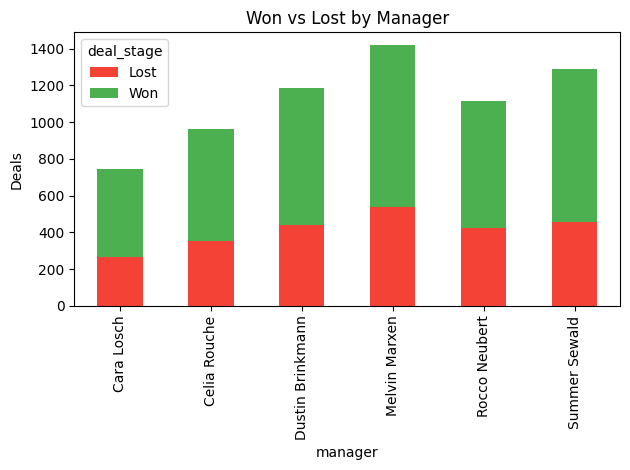

In [25]:
# --- SALES TEAM PERFORMANCE ---
print("\nSALES TEAM PERFORMANCE")
print("="*40)

print("\nManager Performance:")
for mgr in master['manager'].unique():
    df = master[(master['manager'] == mgr) & (master['deal_stage'].isin(['Won','Lost']))]
    if len(df) > 0:
        w = (df['deal_stage'] == 'Won').sum()
        l = (df['deal_stage'] == 'Lost').sum()
        wr = w / len(df) * 100
        rev = df[df['deal_stage'] == 'Won']['close_value'].sum()
        print(f"  {mgr}: Win Rate {wr:.1f}% | Won {w} | Lost {l} | Revenue {rev:,.0f}")

print("\nRegional Performance:")
for reg in master['regional_office'].unique():
    df = master[(master['regional_office'] == reg) & (master['deal_stage'].isin(['Won','Lost']))]
    if len(df) > 0:
        wr = (df['deal_stage'] == 'Won').sum() / len(df) * 100
        rev = df[df['deal_stage'] == 'Won']['close_value'].sum()
        print(f"  {reg}: Win Rate {wr:.1f}% | Revenue {rev:,.0f}")

print("\nTop 10 Agents by Revenue:")
agent_rev = won_deals.groupby('sales_agent')['close_value'].agg(['sum','count']).round(0)
agent_rev.columns = ['revenue', 'deals']
agent_rev = agent_rev.sort_values('revenue', ascending=False).head(10)
print(agent_rev)

open_deals = master[master['deal_stage'].isin(['Engaging', 'Prospecting'])]
print(f"\nOpen/Stalled deals: {len(open_deals)}")
stalled_mgr = open_deals.groupby('manager').size().sort_values(ascending=False)
print("Stalled by manager:")
print(stalled_mgr)
plt.figure(figsize=(8, 4))
mgr_data = master[master['deal_stage'].isin(['Won','Lost'])].groupby('manager')['deal_stage'].value_counts().unstack(fill_value=0)
mgr_data.plot(kind='bar', stacked=True, color=['#f44336','#4CAF50'])
plt.title('Won vs Lost by Manager')
plt.ylabel('Deals')
plt.tight_layout()
plt.savefig('manager_performance.png')
plt.show()


PRODUCT PERFORMANCE
                  revenue  deals  avg_deal  avg_discount
product                                                 
GTXPro          3510578.0    729    4815.6           NaN
GTX Plus Pro    2629651.0    479    5489.9          -0.1
MG Advanced     2216387.0    654    3389.0           0.1
GTX Plus Basic   705275.0    653    1080.1           1.5
GTX Basic        499263.0    915     545.6           0.8
GTK 500          400612.0     15   26707.5           0.2
MG Special        43768.0    793      55.2          -0.4


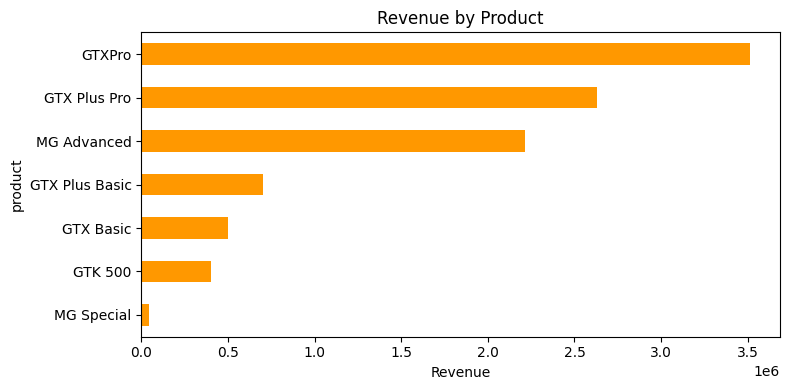

In [27]:
# --- PRODUCT PERFORMANCE ---
print("\nPRODUCT PERFORMANCE")
print("="*40)

prod_perf = won_deals.groupby('product').agg(
    revenue=('close_value', 'sum'),
    deals=('close_value', 'count'),
    avg_deal=('close_value', 'mean'),
    avg_discount=('discount_pct', 'mean')
).round(1).sort_values('revenue', ascending=False)
print(prod_perf)
plt.figure(figsize=(8, 4))
prod_perf['revenue'].sort_values().plot(kind='barh', color='#FF9800')
plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.tight_layout()
plt.savefig('product_revenue.png')
plt.show()

In [29]:
print("""
SUMMARY REPORT

DATA CLEANING STEPS:
1. Fixed typo in accounts table: 'technolgy' → 'technology'
2. Filled 70 missing subsidiary_of values with 'Independent'
3. Fixed product name mismatch: 'GTXPro' → 'GTX Pro'
   (This was causing 1,480 deals to lose product data after merge)
4. Converted engage_date and close_date to datetime format
5. Stripped whitespace from all text columns
6. Merged 5 tables into master using: sales_agent, account, product

MERGE APPROACH:
- Started with Sales Pipeline (8,800 rows) as center table
- LEFT JOIN with Sales Team on sales_agent → added manager, region
- LEFT JOIN with Accounts on account → added sector, revenue, employees
- LEFT JOIN with Products on product → added series, sales_price
- Final master: 8,800 rows × 20 columns

--------------------------------------------------------------------
7 KEY INSIGHTS
1. PIPELINE: Win rate is 63.2% (4,238 won / 6,711 closed).
   2,089 deals remain open (1,589 Engaging + 500 Prospecting).
   Pipeline is healthy but ~24% of all deals are stalled.

2. DATA QUALITY: 16.2% of deals (1,425) have NO account linked.
   This means we cannot analyze sector, company size, or location
   for 1 in 6 deals. Root cause: CRM data entry gap.
   ACTION: Make account field mandatory before saving any deal.

3. DATA QUALITY: Product name 'GTXPro' in pipeline didn't match 
   'GTX Pro' in product table, breaking 1,480 product-level joins.
   ACTION: Enforce standardized product names via dropdown, not free text.

4. PRODUCT: GTK 500 has highest avg deal size (26,708) but only 
   15 deals won — very high value but extremely low volume.
   MG Special has lowest avg deal (55) with 793 deals — high volume,
   low value. GTX Pro drives the most revenue (3,510,578).
   ACTION: Investigate if GTK 500 can be scaled — huge revenue potential.

5. SALES TEAM: Cara Losch's team has highest win rate (64.4%) with 
   fewest stalled deals (219). Melvin Marxen's team generates most 
   revenue (2,251,930) but has most stalled deals (511).
   ACTION: Study Cara Losch's team practices. Coach Marxen's team 
   on closing stalled deals — potential revenue recovery is significant.

6. TOP AGENT: Darcel Schlecht generates 1,153,214 revenue with 349 
   deals — more than 2x the next agent. This is a single-point-of-
   failure risk. If Schlecht leaves, ~12% of total revenue is at risk.
   ACTION: Document Schlecht's approach and cross-train other reps.

7. SECTOR: Retail leads by revenue (1,867,528) but entertainment 
   has highest win rate (64.7%) with strong avg deal size (2,650).
   Finance has lowest win rate (61.2%) — consider if finance deals 
   need specialized sales support or adjusted pricing.

----------------------------------------------------------
3 KEY KPIs FOR DAILY DASHBOARD
1. WIN RATE = Won / (Won + Lost) = 63.2%
   - Track weekly to detect sales process health trends
2. AVG DEAL CYCLE = ~133 days (engage to close for won deals)
   - Monitor for early warning of deals going stale

3. AVG DEAL SIZE = varies by product (55 to 26,708)
   - Track by product and region to spot pricing trends


---------------------------------------------------------
CHURN/ACCOUNT-HEALTH MODEL RECOMMENDATION
Top 5 fields to keep:
1. deal_duration — velocity signals engagement health
2. close_value vs sales_price — discount pattern predicts churn risk
3. sector — industry-specific churn patterns
4. deal_stage progression speed — stalled deals = at-risk accounts
5. manager/region — team quality affects retention

Extra data Sciqus should START collecting:
1. Product login frequency (are customers actually using AMS?)
2. Support ticket count per account (high tickets = churn risk)
3. NPS / satisfaction survey scores
4. Contract renewal dates (predict churn 90 days before expiry)
5. Number of active users per account (low usage = churn risk)

Daily product dashboard
Page 1 — Pipeline funnel (deal count + value by stage)
Page 2 — Deals expected to close this week/month
Page 3 — Stalled deals alert (>30 days in Engaging/Prospecting)
Page 4 — Win rate trend (weekly rolling average)
Page 5 — Top accounts by revenue and risk score

Top  3 actions
1. FIX DATA ENTRY: Require account field on all deals.
   16.2% of pipeline is unanalyzable — this blocks AI/ML initiatives.

2. ADDRESS STALLED DEALS: 2,089 open deals need attention.
   Prioritize Melvin Marxen's 511 stalled deals — highest count.
   Implement automated nudges when deals stay in Engaging >30 days.

3. EXPLORE GTK 500 OPPORTUNITY: Avg deal 26,708 but only 15 won.
   If conversion is improved, even 50 more GTK 500 deals/year = 
   1.3M additional revenue. Investigate why volume is so low.
""")


SUMMARY REPORT

DATA CLEANING STEPS:
1. Fixed typo in accounts table: 'technolgy' → 'technology'
2. Filled 70 missing subsidiary_of values with 'Independent'
3. Fixed product name mismatch: 'GTXPro' → 'GTX Pro'
   (This was causing 1,480 deals to lose product data after merge)
4. Converted engage_date and close_date to datetime format
5. Stripped whitespace from all text columns
6. Merged 5 tables into master using: sales_agent, account, product

MERGE APPROACH:
- Started with Sales Pipeline (8,800 rows) as center table
- LEFT JOIN with Sales Team on sales_agent → added manager, region
- LEFT JOIN with Accounts on account → added sector, revenue, employees
- LEFT JOIN with Products on product → added series, sales_price
- Final master: 8,800 rows × 20 columns

--------------------------------------------------------------------
7 KEY INSIGHTS
1. PIPELINE: Win rate is 63.2% (4,238 won / 6,711 closed).
   2,089 deals remain open (1,589 Engaging + 500 Prospecting).
   Pipeline is healthy